# Basic ML models

This notebook compares different ML models to predict the survival of cancer samples:

1. **unimodal** — using only clinical data (age, sexe, etc.)
2. **bimodal** — using clinical data and RNA-seq data (bulk, protein-coding genes, counts normalised with DESeq2)

Both kinds of models predict a **log partial hazard** (Cox linear predictor) for each sample. 
A higher log partial hazard score indicates a higher predicted risk of death, and therefore a shorter expected survival time.

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import pandas as pd
import sklearn as sk
import sksurv

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## EDA

In [22]:
clinical_data = pd.read_csv("../../data/coldata_essaiscliniques_vF.csv")
# clinical_data["BMI"] = clinical_data["Weight"] / (np.square(clinical_data["Height"]/100))
clinical_data.head()

,SampleID,Site,Indication,Nber_treatments,Treat_radio,Treat_immuno,Treat_angio,Treat_monoAb,Treat_chemo,Age,...,Weight,Height,Date_prelevement,Date_traitement,Death_status,OS_traitement,Prog_status,PFS_traitement,OS_prelevement,PFS_prelevement
0,01-001,Primary,LAPC,1,No,No,No,No,Yes,60,...,60.0,160,2023-03-14,2023-04-05,1,621,1,308,643,330
1,01-003,Primary,LAPC,1,No,No,No,No,Yes,59,...,75.0,180,2023-04-13,2023-06-01,1,501,1,442,550,491
2,01-004,Primary,LAPC,1,No,No,No,No,Yes,62,...,86.0,188,2023-04-26,2023-06-06,1,331,1,50,372,91
3,01-006,Primary,LAPC,1,No,No,No,No,Yes,74,...,82.0,165,2023-06-21,2023-07-27,1,495,1,476,531,512
4,01-007,Primary,LAPC,1,No,No,No,No,Yes,59,...,68.0,176,2023-08-07,2023-09-14,0,613,0,613,651,651


In [ ]:
px.scatter(clinical_data, x="OS_prelevement", y="PFS_prelevement", color="Indication", title="Distribution of OS and PFS by Cancer Type")
# one sample sah a negative PFS: that's not per se an error, as the patient progressed before the sampling

In [ ]:
px.box(clinical_data, x="Nber_treatments", y="OS_prelevement", color="Indication", title="Distribution of OS by Cancer Type and Number of Treatments")

In [13]:
px.box(clinical_data, x="Indication", y="OS_prelevement", color="Indication", title="Distribution of OS by Cancer Type")

In [15]:
px.histogram(clinical_data, "OS_prelevement", color="Indication", barmode="overlay", title="Histogram of OS by Cancer Type")

In [16]:
px.histogram(clinical_data, "PFS_prelevement", color="Indication", barmode="overlay", title="Histogram of PFS by Cancer Type")

In [18]:
px.scatter(clinical_data, x="Site", y="OS_prelevement")

In [19]:
px.box(clinical_data, x="Indication", y="OS_prelevement", color="Site", title="Distribution of OS by Cancer Type")

<Axes: xlabel='timeline'>

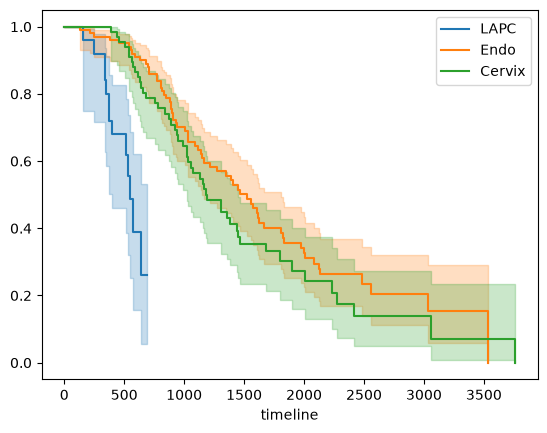

In [11]:
from lifelines import KaplanMeierFitter
km = KaplanMeierFitter() 
groups = clinical_data["Indication"]
i1 = (groups == "LAPC")
i2 = (groups == "Endo")
i3 = (groups == "Cervix")
km.fit(clinical_data.OS_prelevement[i1], clinical_data.Death_status[i1], label='LAPC')
a1 = km.plot()
km.fit(clinical_data.OS_prelevement[i2], clinical_data.Death_status[i2], label='Endo')
a2 = km.plot(ax = a1)
km.fit(clinical_data.OS_prelevement[i3], clinical_data.Death_status[i3], label='Cervix')
km.plot(ax = a2)

## Data preparation

In [23]:
# Removing columns that are IDs and that have a direct link with the variable of interest (OS_prelevement) but keeping the event column (for Cox model)
clinical_data_purged = clinical_data.copy(deep=True)
# clinical_data_purged = clinical_data_purged.loc[clinical_data_purged["Site"] == "Primary",] # to ease the predictions
clinical_data_purged = clinical_data_purged.drop(["SampleID", "Date_prelevement", "Date_traitement", "Prog_status", "OS_traitement", "PFS_traitement", "PFS_prelevement"], axis = 1)

In [59]:
clinical_data_purged["Indication"].value_counts()

Indication
Endo      101
Cervix     67
LAPC       25
Name: count, dtype: int64

In [235]:
# Separate target variable Y from features X
target_variable = "OS_prelevement"
event_variable = "Death_status"
X = clinical_data_purged.drop([target_variable, event_variable], axis = 1)
event_Cox = clinical_data_purged.loc[:,event_variable]
Y = clinical_data_purged.loc[:,target_variable]

# Divide dataset into Train set & Test set 
X_train, X_test, Y_train, Y_test, event_Cox_train, event_Cox_test = train_test_split(X, Y, event_Cox, test_size=0.2, random_state=42, stratify=clinical_data_purged.Indication)

In [236]:
X.head()

,Site,Indication,Nber_treatments,Treat_radio,Treat_immuno,Treat_angio,Treat_monoAb,Treat_chemo,Age,Sex,Weight,Height
0,Primary,LAPC,1,No,No,No,No,Yes,60,F,60.0,160
1,Primary,LAPC,1,No,No,No,No,Yes,59,M,75.0,180
2,Primary,LAPC,1,No,No,No,No,Yes,62,M,86.0,188
3,Primary,LAPC,1,No,No,No,No,Yes,74,F,82.0,165
4,Primary,LAPC,1,No,No,No,No,Yes,59,M,68.0,176


In [215]:
print("means of Y_train and Y_test : ", Y_train.mean(), Y_test.mean())
print("means of event_Cox_train and event_Cox_test : ", event_Cox_train.mean(), event_Cox_test.mean())

means of Y_train and Y_test :  1208.8376623376623 1256.4102564102564
means of event_Cox_train and event_Cox_test :  0.6428571428571429 0.717948717948718


In [237]:
# Transform X_train and X_test 

display(X.dtypes)
numeric_features = ["Nber_treatments", "Age", "Weight", "Height"]
# categorical_features = ["Site", "Indication", "Treat_radio", "Treat_immuno", "Treat_angio", "Treat_monoAb", "Treat_chemo", "Sex"]
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), numeric_features),
#         ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
#     ]
# )
# X_train = preprocessor.fit_transform(X_train)
# X_test = preprocessor.transform(X_test)

from sksurv.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
encoder = OneHotEncoder()
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

Site                   str
Indication             str
Nber_treatments      int64
Treat_radio            str
Treat_immuno           str
Treat_angio            str
Treat_monoAb           str
Treat_chemo            str
Age                  int64
Sex                    str
Weight             float64
Height               int64
dtype: object

In [238]:
# X_train[0:5]
X_train.head()

,Site=Metastasis,Site=Primary,Indication=Endo,Indication=LAPC,Nber_treatments,Treat_radio=Yes,Treat_immuno=Yes,Treat_angio=Yes,Treat_monoAb=Yes,Age,Sex=M,Weight,Height
143,0.0,1.0,1.0,0.0,-0.512199,0.0,0.0,0.0,1.0,0.302917,0.0,0.440086,-1.343303
131,0.0,1.0,1.0,0.0,-0.512199,1.0,1.0,0.0,0.0,0.125206,0.0,0.137365,-0.643477
40,0.0,1.0,1.0,0.0,2.483194,0.0,1.0,0.0,0.0,0.214061,0.0,-1.860595,-2.323060
48,0.0,1.0,0.0,0.0,0.486265,1.0,0.0,1.0,1.0,-0.407928,0.0,0.924440,0.056350
156,0.0,1.0,1.0,0.0,-0.512199,1.0,1.0,0.0,0.0,0.836051,0.0,1.287705,-0.503512


## 1. Unimodal models

### a. Cox model

from: https://scikit-survival.readthedocs.io/en/stable/user_guide/00-introduction.html & https://scikit-survival.readthedocs.io/en/stable/user_guide/evaluating-survival-models.html

In [82]:
event_Cox_str = event_Cox.astype(bool)
event_Cox_train_str = event_Cox_train.astype(bool)
event_Cox_test_str = event_Cox_test.astype(bool)

Y_array = np.array([(event_Cox_str[i], Y[i]) for i in range(len(Y))], dtype=[('event', '?'), ('time', 'i4')])
Y_array_train = np.array([(event_Cox_train_str[i], Y_train[i]) for i in Y_train.index], dtype=[('event', '?'), ('time', 'i4')])
Y_array_test = np.array([(event_Cox_test_str[i], Y_test[i]) for i in Y_test.index], dtype=[('event', '?'), ('time', 'i4')])

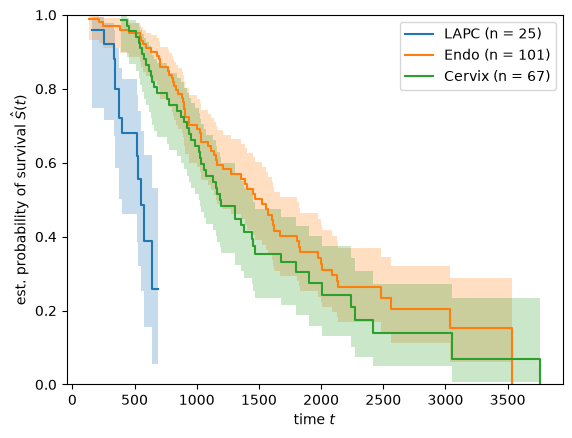

In [ ]:
# Univariate model, for each indication separately

from sksurv.nonparametric import kaplan_meier_estimator

for value in clinical_data_purged["Indication"].unique():
    mask = clinical_data_purged["Indication"] == value
    time_indic, survival_prob_indic, conf_int = kaplan_meier_estimator(
        Y_array["event"][mask], Y_array["time"][mask], conf_type="log-log"
    )
    plt.step(time_indic, survival_prob_indic, where="post", label=f"{value} (n = {mask.sum()})")
    plt.fill_between(time_indic, conf_int[0], conf_int[1], alpha=0.25, step="post")

plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.legend(loc="best")


In [239]:
# Multivariate model

from sklearn import set_config
from sksurv.linear_model import CoxPHSurvivalAnalysis

set_config(display="text")  # displays text representation of estimators

cph = CoxPHSurvivalAnalysis()
cph.fit(X_train, Y_array_train)
pd.Series(cph.coef_, index=X_train.columns)

Site=Metastasis    -0.416036
Site=Primary       -0.632309
Indication=Endo    -0.506208
Indication=LAPC     0.985916
Nber_treatments    -0.144333
Treat_radio=Yes    -0.463941
Treat_immuno=Yes    0.167128
Treat_angio=Yes    -0.239350
Treat_monoAb=Yes   -0.217996
Age                 0.030852
Sex=M               0.147243
Weight             -0.161459
Height              0.062418
dtype: float64

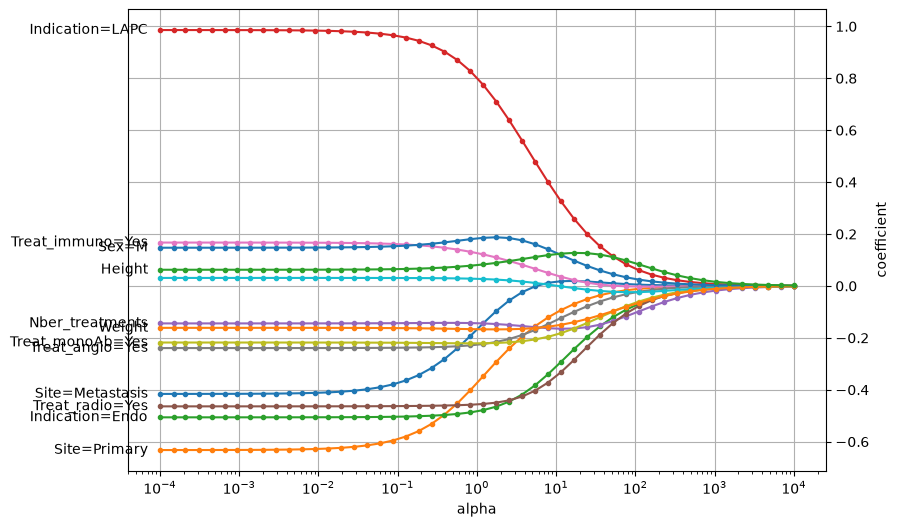

In [240]:
# penalized Cox model, to see which features are important : Ridge

alphas = 10.0 ** np.linspace(-4, 4, 50)
coefficients = {}

estimator = CoxPHSurvivalAnalysis()
for alpha in alphas:
    estimator.set_params(alpha=alpha)
    estimator.fit(X_train, Y_array_train)
    key = round(alpha, 5)
    coefficients[key] = estimator.coef_

coefficients = pd.DataFrame.from_dict(coefficients).rename_axis(index="feature", columns="alpha").set_index(X_train.columns)

def plot_coefficients(coefs, n_highlight):
    _, ax = plt.subplots(figsize=(9, 6))
    alphas = coefs.columns
    for row in coefs.itertuples():
        ax.semilogx(alphas, row[1:], ".-", label=row.Index)

    alpha_min = alphas.min()
    top_coefs = coefs.loc[:, alpha_min].map(abs).sort_values().tail(n_highlight)
    for name in top_coefs.index:
        coef = coefs.loc[name, alpha_min]
        plt.text(alpha_min, coef, name + "   ", horizontalalignment="right", verticalalignment="center")

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.grid(True)
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient")

plot_coefficients(coefficients, n_highlight=X.shape[1])

# Indication=LAPC and Site=Primary separate themselves from the remaining coefficients, which indicates that these particular features are important predictive factors for time to distant death

In [241]:
# Measure the performance of the model on the test set

from sksurv.metrics import concordance_index_censored, concordance_index_ipcw

# prediction = cph.predict(X_test)
# result = concordance_index_censored(Y_array_test["event"], Y_array_test["time"], prediction)
# f"{result[0]:.5f}"
c_index = cph.score(X_test, Y_array_test)
f"{c_index:.5f}"

# prediction = cph.predict(X_test)
# result = concordance_index_ipcw(Y_array_train, Y_array_test, prediction)
# f"{result[0]:.5f}"

'0.64071'

In [242]:
# Feature selection

def fit_and_score_features(X, y):
    n_features = X.shape[1]
    scores = np.empty(n_features)
    m = CoxPHSurvivalAnalysis()
    for j in range(n_features):
        Xj = X[:, j : j + 1]
        m.fit(Xj, y)
        scores[j] = m.score(Xj, y)
    return scores


scores = fit_and_score_features(X_train.values, Y_array_train)
display(pd.Series(scores, index=X_train.columns).sort_values(ascending=False))

from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline
pipe = Pipeline(
    [
        ("encode", OneHotEncoder()),
        ("select", SelectKBest(fit_and_score_features, k=3)),
        ("model", CoxPHSurvivalAnalysis()),
    ]
)

from sklearn.model_selection import KFold

param_grid = {"select__k": np.arange(1, X_train.shape[1] + 1)}
cv = KFold(n_splits=3, random_state=1, shuffle=True)
gcv = GridSearchCV(pipe, param_grid, return_train_score=True, cv=cv)
gcv.fit(X, Y_array)

results = pd.DataFrame(gcv.cv_results_).sort_values(by="mean_test_score", ascending=False)
results.loc[:, ~results.columns.str.endswith("_time")]

# it seems we need to keep at least 10 features

Nber_treatments     0.580655
Treat_radio=Yes     0.573944
Height              0.572713
Indication=Endo     0.571481
Indication=LAPC     0.566186
Treat_monoAb=Yes    0.565694
Weight              0.548639
Sex=M               0.528137
Treat_angio=Yes     0.526475
Treat_immuno=Yes    0.525120
Site=Primary        0.523150
Site=Metastasis     0.516993
Age                 0.515454
dtype: float64

,param_select__k,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
9,10,{'select__k': 10},0.623224,0.666667,0.661382,0.650424,0.019354,1,0.691890,0.664186,0.634658,0.663578,0.023369
10,11,{'select__k': 11},0.623224,0.667627,0.648066,0.646306,0.018170,2,0.692452,0.661860,0.633742,0.662685,0.023975
5,6,{'select__k': 6},0.615195,0.678194,0.644261,0.645883,0.025745,3,0.649466,0.648217,0.629440,0.642374,0.009160
11,12,{'select__k': 12},0.612724,0.680115,0.639188,0.644009,0.027723,4,0.690766,0.660310,0.635298,0.662125,0.022681
4,5,{'select__k': 5},0.616430,0.671470,0.643627,0.643842,0.022470,5,0.648436,0.644186,0.629348,0.640657,0.008182
6,7,{'select__k': 7},0.613342,0.669549,0.643310,0.642067,0.022963,6,0.675126,0.651163,0.628891,0.651727,0.018880
7,8,{'select__k': 8},0.615812,0.663785,0.645212,0.641603,0.019750,7,0.674752,0.664186,0.628158,0.655699,0.019946
3,4,{'select__k': 4},0.603459,0.665226,0.648066,0.638917,0.026033,8,0.648717,0.623178,0.632827,0.634907,0.010529
8,9,{'select__k': 9},0.609018,0.662824,0.640774,0.637539,0.022085,9,0.672411,0.663721,0.631637,0.655923,0.017535
2,3,{'select__k': 3},0.581532,0.657061,0.634432,0.624342,0.031649,10,0.637854,0.607674,0.625961,0.623830,0.012412


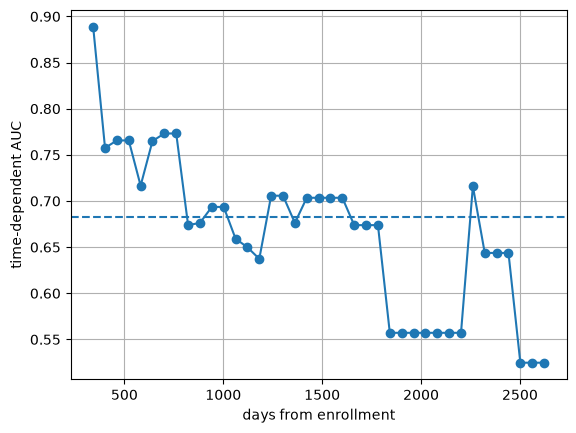

In [243]:
# ROC to assess how well the model can distinguish survivors from deceased in bi-monthly intervals

from sksurv.metrics import cumulative_dynamic_auc

# we need to remove from X_test and Y_test time points longer than the max of Y_train, otherwise we get the error "censoring survival function is zero at one or more time points"
max_timepoint = max(Y_train)
incorrect_tests = Y_test[Y_test > max_timepoint].index
X_test_purged = X_test.loc[~X_test.index.isin(incorrect_tests)]
Y_test_purged = Y_test.loc[~Y_test.index.isin(incorrect_tests)]
event_Cox_test_str_purged = event_Cox_test_str.loc[~event_Cox_test_str.index.isin(incorrect_tests)]
Y_array_test_purged = np.array([(event_Cox_test_str_purged[i], Y_test_purged[i]) for i in Y_test_purged.index], dtype=[('event', '?'), ('time', 'i4')])

va_times = np.arange(min(Y_test_purged), max(Y_test_purged), 60)
cph_risk_scores = cph.predict(X_test_purged)
cph_auc, cph_mean_auc = cumulative_dynamic_auc(Y_array_train, Y_array_test_purged, cph_risk_scores, va_times)

plt.plot(va_times, cph_auc, marker="o")
plt.axhline(cph_mean_auc, linestyle="--")
plt.xlabel("days from enrollment")
plt.ylabel("time-dependent AUC")
plt.grid(True)

In [244]:
px.scatter(x=Y_test_purged.values, y=X_test_purged["Indication=LAPC"])

# the LAPC explain the high AUC for small x, as these patients have a very short survival time

In [253]:
coxnet = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100)
coxnet.fit(X_train, Y_array_train)
coxnet.alphas_

array([0.14501763, 0.13842636, 0.13213467, 0.12612894, 0.12039619,
       0.11492399, 0.10970052, 0.10471446, 0.09995503, 0.09541192,
       0.0910753 , 0.08693579, 0.08298442, 0.07921265, 0.07561231,
       0.07217562, 0.06889512, 0.06576374, 0.06277467, 0.05992147,
       0.05719794, 0.05459821, 0.05211664, 0.04974785, 0.04748674,
       0.04532839, 0.04326815, 0.04130154, 0.03942432, 0.03763243,
       0.03592198, 0.03428927, 0.03273077, 0.0312431 , 0.02982305,
       0.02846755, 0.02717366, 0.02593857, 0.02475962, 0.02363426,
       0.02256005, 0.02153466, 0.02055587, 0.01962158, 0.01872975,
       0.01787845, 0.01706585, 0.01629018, 0.01554977, 0.014843  ,
       0.01416837, 0.01352439, 0.01290969, 0.01232292, 0.01176283,
       0.01122819, 0.01071785, 0.01023071, 0.00976571, 0.00932184,
       0.00889815, 0.00849371, 0.00810766, 0.00773915, 0.0073874 ,
       0.00705163, 0.00673112, 0.00642518, 0.00613315, 0.00585439,
       0.0055883 , 0.0053343 , 0.00509185, 0.00486041, 0.00463

In [254]:
coxnet = make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100))
coxnet.fit(X_train, Y_array_train)
coxnet.named_steps["coxnetsurvivalanalysis"].alphas_

array([0.16832181, 0.16067132, 0.15336856, 0.14639772, 0.13974372,
       0.13339215, 0.12732927, 0.12154196, 0.11601769, 0.11074451,
       0.105711  , 0.10090627, 0.09631993, 0.09194204, 0.08776313,
       0.08377416, 0.07996649, 0.07633189, 0.07286249, 0.06955078,
       0.06638959, 0.06337208, 0.06049172, 0.05774228, 0.0551178 ,
       0.05261261, 0.05022129, 0.04793865, 0.04575977, 0.04367992,
       0.0416946 , 0.03979951, 0.03799056, 0.03626383, 0.03461559,
       0.03304225, 0.03154043, 0.03010687, 0.02873847, 0.02743226,
       0.02618542, 0.02499525, 0.02385918, 0.02277474, 0.0217396 ,
       0.0207515 , 0.01980831, 0.01890799, 0.0180486 , 0.01722826,
       0.01644521, 0.01569775, 0.01498426, 0.0143032 , 0.0136531 ,
       0.01303255, 0.0124402 , 0.01187477, 0.01133504, 0.01081985,
       0.01032807, 0.00985864, 0.00941055, 0.00898283, 0.00857455,
       0.00818482, 0.00781281, 0.0074577 , 0.00711874, 0.00679518,
       0.00648633, 0.00619152, 0.0059101 , 0.00564148, 0.00538

Number of non-zero coefficients: 6


/tmp/ipykernel_31545/2569984091.py:56: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)


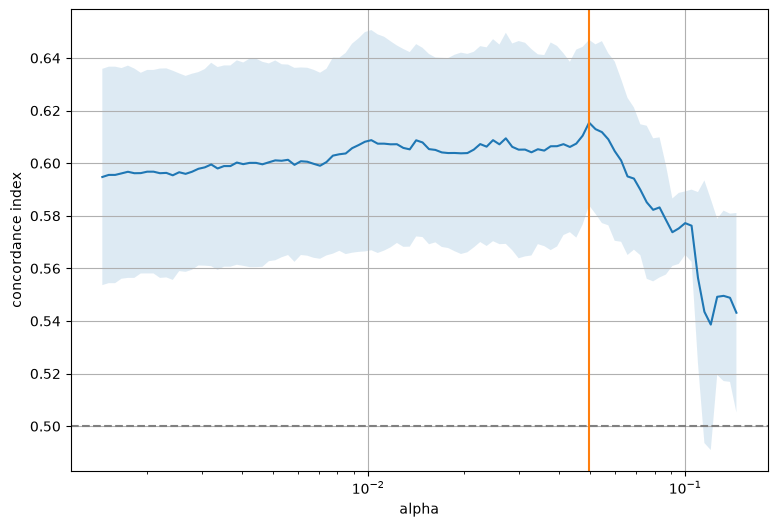

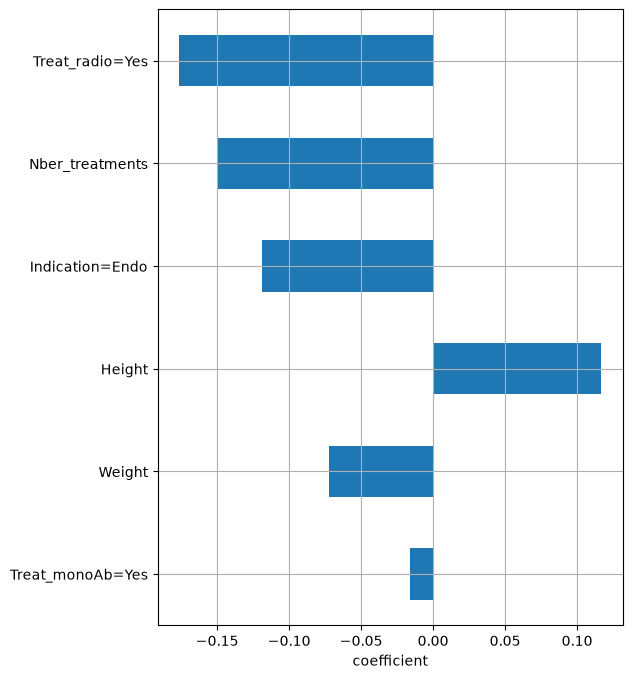

In [264]:
# Cox’s proportional hazard’s model with elastic net penalty: finding alpha

import warnings
from sklearn.exceptions import FitFailedWarning
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.pipeline import make_pipeline

# coxnet = make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100))
coxnet = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FitFailedWarning)
coxnet.fit(X_train, Y_array_train)

# estimated_alphas = coxnet.named_steps["coxnetsurvivalanalysis"].alphas_
estimated_alphas = coxnet.alphas_
cv = KFold(n_splits=5, shuffle=True, random_state=0)
gcv = GridSearchCV(
    # make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9)),
    # param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in map(float, estimated_alphas)]},
    CoxnetSurvivalAnalysis(l1_ratio=0.9),
    param_grid={"alphas": [[v] for v in map(float, estimated_alphas)]},
    cv=cv,
    error_score=0.5,
    n_jobs=1,
).fit(X_train, Y_array_train)

cv_results = pd.DataFrame(gcv.cv_results_)

# alphas = cv_results.param_coxnetsurvivalanalysis__alphas.map(lambda x: x[0])
alphas = cv_results.param_alphas.map(lambda x: x[0]) 
mean = cv_results.mean_test_score
std = cv_results.std_test_score

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas, mean)
ax.fill_between(alphas, mean - std, mean + std, alpha=0.15)
ax.set_xscale("log")
ax.set_ylabel("concordance index")
ax.set_xlabel("alpha")
# ax.axvline(gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], c="C1")
ax.axvline(gcv.best_params_["alphas"][0], c="C1")
ax.axhline(0.5, color="grey", linestyle="--")
ax.grid(True)

# best_model = gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"]
best_model = gcv.best_estimator_
best_coefs = pd.DataFrame(best_model.coef_, index=X_train.columns, columns=["coefficient"])

non_zero = np.sum(best_coefs.iloc[:, 0] != 0)
print(f"Number of non-zero coefficients: {non_zero}")

non_zero_coefs = best_coefs.query("coefficient != 0")
coef_order = non_zero_coefs.abs().sort_values("coefficient").index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
ax.set_xlabel("coefficient")
ax.grid(True)

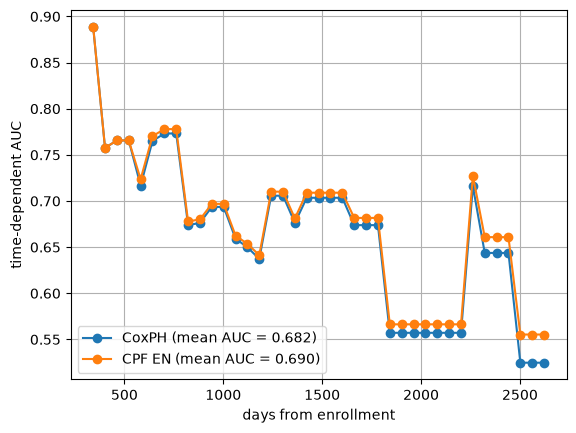

In [265]:
# Cox’s proportional hazard’s model with elastic net penalty

# cph_en = CoxnetSurvivalAnalysis(l1_ratio=gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], fit_baseline_model=True)
cph_en = CoxnetSurvivalAnalysis(l1_ratio=gcv.best_params_["alphas"][0], fit_baseline_model=True)
cph_en.fit(X_train, Y_array_train)

cph_en_chf_funcs = cph_en.predict_cumulative_hazard_function(X_test_purged, return_array=False)
cph_en_risk_scores = np.vstack([chf(va_times) for chf in cph_en_chf_funcs])

cph_en_auc, cph_en_mean_auc = cumulative_dynamic_auc(Y_array_train, Y_array_test_purged, cph_en_risk_scores, va_times)

plt.plot(va_times, cph_auc, "o-", label=f"CoxPH (mean AUC = {cph_mean_auc:.3f})")
plt.plot(va_times, cph_en_auc, "o-", label=f"CPF EN (mean AUC = {cph_en_mean_auc:.3f})")
plt.xlabel("days from enrollment")
plt.ylabel("time-dependent AUC")
plt.legend(loc="lower left")
plt.grid(True) 

In [ ]:
# from lifelines import CoxPHFitter
# cph = CoxPHFitter()
# cph.fit(clinical_data_purged, 'OS_prelevement', event_col='Death_status')
# cph.print_summary()

### b. Random Survival Forest 

from: https://scikit-survival.readthedocs.io/en/stable/user_guide/evaluating-survival-models.html

In [274]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import as_concordance_index_ipcw_scorer, as_cumulative_dynamic_auc_scorer, as_integrated_brier_score_scorer

cv = KFold(n_splits=3, shuffle=True, random_state=1)
cv_param_grid = {
    "estimator__max_depth": np.arange(1, 10, dtype=int),
    "estimator__min_samples_leaf": np.arange(1, 10, dtype=int),
    "estimator__n_estimators": np.arange(1, 350, step=50, dtype=int),
}

rsf = RandomSurvivalForest(random_state=42)
rsf.fit(X_train, Y_array_train)

lower, upper = np.percentile(Y_array_train["time"], [10, 90])
times = np.arange(lower, upper + 1)

gcv_cindex = GridSearchCV(
    as_concordance_index_ipcw_scorer(rsf, tau=times[-1]),
    param_grid=cv_param_grid,
    cv=cv,
).fit(X_train, Y_array_train)
gcv_iauc = GridSearchCV(
    as_cumulative_dynamic_auc_scorer(rsf, times=times),
    param_grid=cv_param_grid,
    cv=cv,
).fit(X_train, Y_array_train)
gcv_ibs = GridSearchCV(
    as_integrated_brier_score_scorer(rsf, times=times),
    param_grid=cv_param_grid,
    cv=cv,
).fit(X_train, Y_array_train)

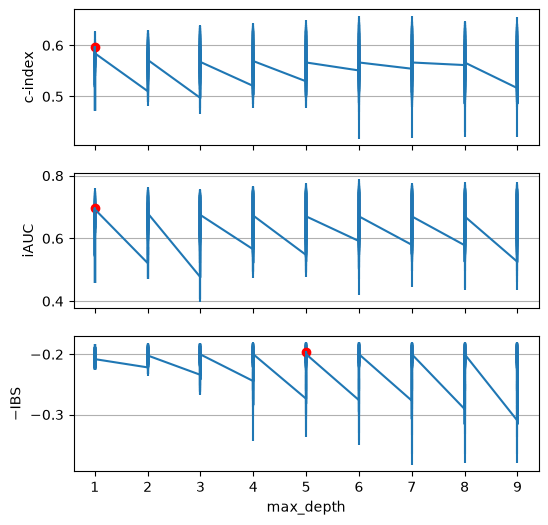

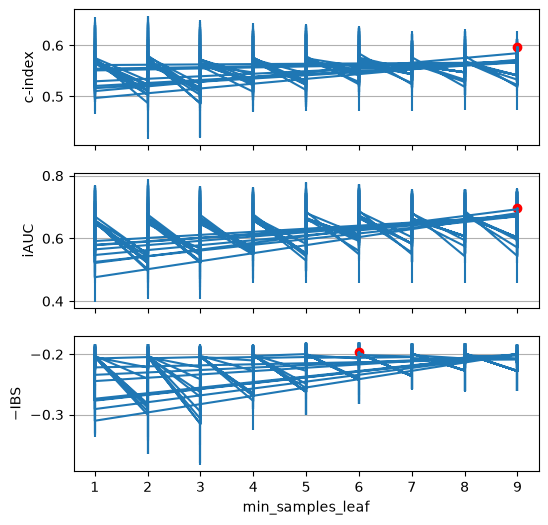

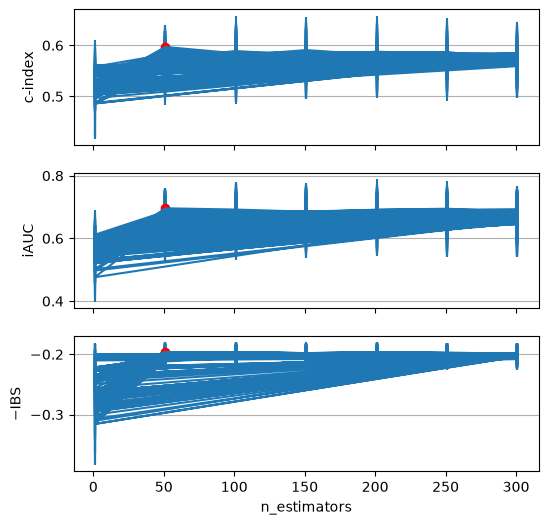

In [ ]:
def plot_grid_search_results(gcv, ax, name, x_axis_name):
    ax.errorbar(
        x=gcv.cv_results_["param_estimator__" + x_axis_name].filled(),
        y=gcv.cv_results_["mean_test_score"],
        yerr=gcv.cv_results_["std_test_score"],
    )
    ax.plot(
        gcv.best_params_["estimator__" + x_axis_name],
        gcv.best_score_,
        "ro",
    )
    ax.set_ylabel(name)
    ax.yaxis.grid(True)


_, axs = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
axs[-1].set_xlabel("max_depth")

plot_grid_search_results(gcv_cindex, axs[0], "c-index", "max_depth")
plot_grid_search_results(gcv_iauc, axs[1], "iAUC", "max_depth")
plot_grid_search_results(gcv_ibs, axs[2], "$-$IBS", "max_depth") # a lower Brier score indicates better performance

_, axs = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
axs[-1].set_xlabel("min_samples_leaf")

plot_grid_search_results(gcv_cindex, axs[0], "c-index", "min_samples_leaf")
plot_grid_search_results(gcv_iauc, axs[1], "iAUC", "min_samples_leaf")
plot_grid_search_results(gcv_ibs, axs[2], "$-$IBS", "min_samples_leaf")

_, axs = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
axs[-1].set_xlabel("n_estimators")

plot_grid_search_results(gcv_cindex, axs[0], "c-index", "n_estimators")
plot_grid_search_results(gcv_iauc, axs[1], "iAUC", "n_estimators")
plot_grid_search_results(gcv_ibs, axs[2], "$-$IBS", "n_estimators")

results:
- max_depth: at 1 for the concordance index and iAUC, at 5 for -IBS -> I choose 2
- min_samples_leaf: at 9 for c-index and iAUC, 6 for -IBS -> I choose 9
- n_estimators: at 50 for the three -> I choose 50

In [276]:
rsf = make_pipeline(OneHotEncoder(), RandomSurvivalForest(max_depth=2, n_estimators=50, min_samples_leaf=9, random_state=42))
rsf.fit(X_train, Y_array_train)

Pipeline(steps=[('onehotencoder', OneHotEncoder()),
                ('randomsurvivalforest',
                 RandomSurvivalForest(max_depth=2, min_samples_leaf=9,
                                      n_estimators=50, random_state=42))])

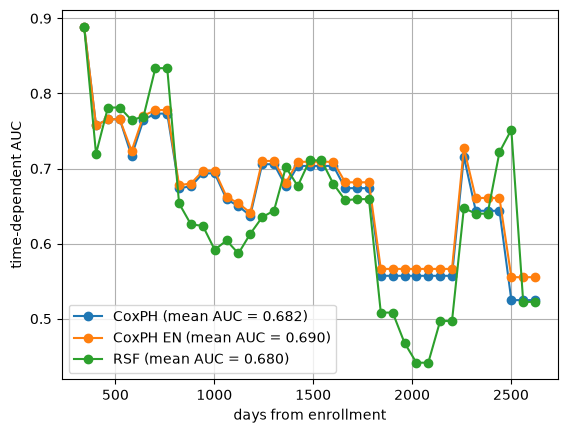

In [277]:
# Comparison with predictions from Cox proportional hazards models (above)

rsf_chf_funcs = rsf.predict_cumulative_hazard_function(X_test_purged, return_array=False)
rsf_risk_scores = np.vstack([chf(va_times) for chf in rsf_chf_funcs])

rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(Y_array_train, Y_array_test_purged, rsf_risk_scores, va_times)

plt.plot(va_times, cph_auc, "o-", label=f"CoxPH (mean AUC = {cph_mean_auc:.3f})")
plt.plot(va_times, cph_en_auc, "o-", label=f"CoxPH EN (mean AUC = {cph_en_mean_auc:.3f})")
plt.plot(va_times, rsf_auc, "o-", label=f"RSF (mean AUC = {rsf_mean_auc:.3f})")
plt.xlabel("days from enrollment")
plt.ylabel("time-dependent AUC")
plt.legend(loc="lower left")
plt.grid(True) 

In [278]:
# Scores of the three models: measured by the concordance index & the Brier score

score_cindex = pd.Series(
    [
        rsf.score(X_test, Y_array_test),
        cph.score(X_test, Y_array_test),
        cph_en.score(X_test, Y_array_test),
        0.5,
    ],
    index=["RSF", "CPH", "CPH_EN", "Random"],
    name="c-index",
)

rsf_surv_prob = np.vstack([fn(times) for fn in rsf.predict_survival_function(X_test)])
cph_surv_prob = np.vstack([fn(times) for fn in cph.predict_survival_function(X_test)])
cph_en_surv_prob = np.vstack([fn(times) for fn in cph_en.predict_survival_function(X_test)])
random_surv_prob = 0.5 * np.ones((Y_array_test.shape[0], times.shape[0]))

from sksurv.functions import StepFunction
km_func = StepFunction(*kaplan_meier_estimator(Y_array_test["event"], Y_array_test["time"]))
km_surv_prob = np.tile(km_func(times), (Y_array_test.shape[0], 1))

from sksurv.metrics import integrated_brier_score
score_brier = pd.Series(
    [
        integrated_brier_score(Y_array, Y_array_test, prob, times)
        for prob in (rsf_surv_prob, cph_surv_prob, cph_en_surv_prob, random_surv_prob, km_surv_prob)
    ],
    index=["RSF", "CPH", "CPH_EN", "Random", "Kaplan-Meier"],
    name="IBS",
)

pd.concat((score_cindex, score_brier), axis=1).round(3)

# both CPH models are better than the RSF model

,c-index,IBS
RSF,0.604,0.194
CPH,0.641,0.187
CPH_EN,0.642,0.187
Random,0.500,0.256
Kaplan-Meier,NaN,0.209


## 2. Bimodal models

### a. Data preparation

Incorporating the RNA-Seq data into X

In [ ]:
# Removing the samples which had bad QC metrics (i.e. sample 06-006 from LapNet that was not sequenced properly)

